
**Déroulé du notebook, étape par étape** :
1. Installation et correctifs (NumPy/fastText)
2. Chargement des modèles (bge-m3, ChromaDB, fastText, Qwen3-8B)
3. Portage du pipeline (orchestrateur, SCCC, sécurité, prompts)
4. Chargement de 100 cas
5. Exécution complète sur les 50 cas R1 (clinique)
6. Exécution complète sur les 50 cas R2 (éducatif)
7. Statistiques de synthèse et 4 figures
8. Export final CSV complets 

## Ce qu'on teste, et comment

Ce notebook ne teste pas un seul "gros bloc" — il teste **chaque composant de
mon architecture séparément**, en observant son effet dans le pipeline réel :

| Composant de l'architecture | Ce qu'on vérifie | Comment (colonne du résultat) |
|---|---|---|
| **Orchestrateur** (langue, rôle, crise, hors-scope) | Détecte-t-il correctement, sur du contenu réel ? | `role_detecte`, `securite1_crise`, `securite1_hors_scope` |
| **RAG** (bge-m3 + ChromaDB) | Récupère-t-il des documents pertinents selon le rôle ? | Implicite dans la qualité de la réponse et le pilier `sccc_source` |
| **Agent 1 (clinique)** | Répond-il utilement, dans la bonne langue, en citant ses sources ? | `reponse_complete`, `sccc_citation` |
| **Agent 2 (éducatif)** | Respecte-t-il la structure Définition→Explication→Exemple ? | `reponse_complete` |
| **SCCC** | Le score réagit-il à la complétude réelle de la vignette ? | `sccc_total` comparé à `statut_attendu` |
| **Sécurité post-traitement** | Bloque-t-il à tort du contenu légitime (faux positif) ? | `securite2_status` sur ces 100 cas, qui sont tous légitimes |

**La méthode** : on ne se contente pas de lire un score global — on
compare **ce que le système devait détecter** (mes colonnes `statut_vignette`,
`elements_manquants`) à **ce qu'il détecte réellement**, cas par cas.

## Étape 1 — Installation et correctifs


In [ ]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip install -q bitsandbytes accelerate "transformers==4.51.3" chromadb==1.5.9 sentence-transformers fasttext-wheel pandas numpy scikit-learn matplotlib

import re, time, json
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive

if "_pristine_np_array" not in globals():
    _pristine_np_array = np.array

def _patched_np_array(*args, **kwargs):
    if kwargs.get("copy") is False:
        kwargs["copy"] = True
    return _pristine_np_array(*args, **kwargs)
np.array = _patched_np_array

if not torch.cuda.is_available():
    raise RuntimeError("GPU requis (Runtime > Change runtime type > GPU).")
print(f"GPU : {torch.cuda.get_device_name(0)}")

drive.mount('/content/drive')
BASE_DRIVE = '/content/drive/MyDrive/Master_Thesis_RAG_Indexes'
VECTOR_DB_DIR = f"{BASE_DRIVE}/Vector_Database/chroma_db_v1"
CAS_DIR = f"{BASE_DRIVE}/Cas_Cliniques"
RESULTS_DIR = f"{BASE_DRIVE}/Resultats_100_Cas"
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Cas cliniques attendus dans : {CAS_DIR}")
print(f"Resultats sauvegardes dans : {RESULTS_DIR}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.4/71.4 kB 7.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 76.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 59.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.1/23.1 MB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.2/137.2 kB 6.1 MB/s eta 0

## Étape 2 — Chargement des modèles

In [ ]:
# Charge le modèle d'embedding (bge-m3) et connecte la base vectorielle ChromaDB déjà construite. La fonction retrieve() est ce qui permet de tester le RAG : elle interroge la base filtrée par rôle (R1/R2).

from sentence_transformers import SentenceTransformer
embed_model = SentenceTransformer("BAAI/bge-m3", device="cuda").half()

def compute_query_embedding(text):
    return embed_model.encode([text], normalize_embeddings=True)[0]

import chromadb
client = chromadb.PersistentClient(path=VECTOR_DB_DIR)
collection = client.get_collection("psych_kb_v1")
print(f"Collection ChromaDB : {collection.count()} documents")

def retrieve(question, role, n_results=5):
    metadata_field = "role_clinical" if role == "clinical" else "role_education"
    query_embedding = compute_query_embedding(question).tolist()
    results = collection.query(query_embeddings=[query_embedding], n_results=n_results, where={metadata_field: True})
    docs, metas, ids = results["documents"][0], results["metadatas"][0], results["ids"][0]
    return [{"text": d, "metadata": m, "id": i} for d, m, i in zip(docs, metas, ids)]

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

...

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Collection ChromaDB : 51854 documents


In [ ]:
# Diagnostic informatif — volumétrie par type de
# contenu dans la base (rôle clinique). Version paginée : récupère les IDs par
# lots de 500 plutôt que tout d'un coup, pour éviter le crash "too many SQL
# variables" rencontré sur les catégories volumineuses (Shifaa notamment).

def compter_par_type(content_type, taille_lot=500):
    total = 0
    decalage = 0
    while True:
        lot = collection.get(
            where={"$and": [{"role_clinical": True}, {"content_type": content_type}]},
            limit=taille_lot,
            offset=decalage,
            include=[]  # ni documents ni embeddings, juste les identifiants plus léger
        )
        n = len(lot["ids"])
        total += n
        if n < taille_lot:
            break
        decalage += taille_lot
    return total

print("Volumétrie par type de contenu (rôle clinique) :")
for content_type in ["clinical_guideline", "clinical_dialogue", "patient_testimony"]:
    total = compter_par_type(content_type)
    print(f"  {content_type} : {total} documents")

Volumétrie par type de contenu (rôle clinique) :
  clinical_guideline : 1942 documents
  clinical_dialogue : 34912 documents
  patient_testimony : 0 documents


In [ ]:
# Charge fastText qui est un modèle entraîné teste la détection de langue.

!wget -q -nc https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.ftz -O /content/lid.176.ftz
import fasttext
fasttext_model = fasttext.load_model("/content/lid.176.ftz")
print("fastText charge")

fastText charge


In [ ]:
# Charge Qwen3-8B 
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
BASE_MODEL_ID = "Qwen/Qwen3-8B"
bnb_config = BitsAndBytesConfig(load_in_4bit=True, bnb_4bit_quant_type="nf4", bnb_4bit_compute_dtype=torch.float16, bnb_4bit_use_double_quant=True)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_ID, trust_remote_code=False)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
model = AutoModelForCausalLM.from_pretrained(BASE_MODEL_ID, quantization_config=bnb_config, device_map={"": 0}, trust_remote_code=False)
print(f"{BASE_MODEL_ID} charge")

def generate(prompt, max_new_tokens=450, temperature=0.7):
    rendered = tokenizer.apply_chat_template([{"role": "user", "content": prompt}], tokenize=False, add_generation_prompt=True, enable_thinking=False)
    # Correction critique : max_length=3000 tronquait la FIN du prompt (la
    # question et l'instruction de langue) quand le contexte RAG était long,
    # laissant le modèle "compléter" des bribes de documents sans jamais voir
    # la vraie consigne. Qwen3-8B supporte 32K tokens nativement ; 6000 reste
    # largement sûr côté mémoire tout en couvrant le prompt en entier.
    inputs = tokenizer(rendered, return_tensors="pt", truncation=True, max_length=6000).to(model.device)
    t0 = time.time()
    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=max_new_tokens, temperature=temperature, do_sample=temperature > 0)
    gen_time = time.time() - t0
    raw = tokenizer.decode(output[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    answer = re.sub(r"<think>.*?</think>", "", raw, flags=re.DOTALL).strip()
    return {"answer": answer, "generation_time_sec": round(gen_time, 2), "prompt_tokens": inputs["input_ids"].shape[1]}

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/728 [00:00<?, ?B/s]

...

model-00005-of-00005.safetensors:   0%|          | 0.00/1.24G [00:00<?, ?B/s]

model-00003-of-00005.safetensors:   0%|          | 0.00/3.96G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

Qwen/Qwen3-8B charge


## Étape 3 — Portage du pipeline complet (orchestrateur, prompts)

In [ ]:
# Porte l'orchestrateur (détection de langue, de rôle,
# de crise, de demande hors-scope) — teste la première étape de pipeline,
# celle qui décide quoi faire du message AVANT tout appel au modèle génératif.

SUPPORTED_LANGUAGES = ["ar", "fr", "en"]

def detect_language(text):
    clean_text = text.replace("\n", " ")
    FUNCTION_WORDS = {"fr": [" le ", " la ", " les ", " est ", " et ", " un ", " une ", " c'est ", " qu'est-ce ", " quoi "], "ar": [" هو ", " هي ", " ما ", " ماذا ", " هل ", " في ", " من "]}
    padded = f" {clean_text.lower()} "
    for lang, words in FUNCTION_WORDS.items():
        if any(w in padded for w in words):
            return lang
    predictions = fasttext_model.predict(clean_text, k=1)
    lang_code = predictions[0][0].replace("__label__", "")
    return lang_code if lang_code in SUPPORTED_LANGUAGES else "en"

CLINICAL_KEYWORDS = {"ar": ["مريض", "تشخيص", "أعراض", "جرعة", "العلاج", "حالة سريرية", "المعايير التشخيصية"], "fr": ["patient", "diagnostic différentiel", "posologie", "critères diagnostiques", "prise en charge", "comorbidité", "tableau clinique", "quelle conduite", "quels éléments", "quelle évaluation", "quel bilan", "quel suivi"], "en": ["patient", "differential diagnosis", "dosage", "diagnostic criteria", "clinical presentation", "comorbidity", "management plan", "what workup", "what assessment", "what management"]}
EDUCATIONAL_KEYWORDS = {"ar": ["ما هو", "اشرح لي", "أريد أن أفهم", "مثال", "تعريف", "هل صحيح", "ما الفرق"], "fr": ["qu'est-ce que", "explique-moi", "je veux comprendre", "exemple", "définition", "est-il vrai", "quelle est la différence", "comment reconnaître"], "en": ["what is", "explain to me", "i want to understand", "example", "definition", "is it true", "what is the difference", "how can you recognise"]}
ROLE_DETECTION_CONFIDENCE_THRESHOLD = 0.6

def detect_role(text, lang):
    text_lower = text.lower()
    clinical_hits = sum(1 for kw in CLINICAL_KEYWORDS.get(lang, []) if kw.lower() in text_lower)
    educational_hits = sum(1 for kw in EDUCATIONAL_KEYWORDS.get(lang, []) if kw.lower() in text_lower)
    total = clinical_hits + educational_hits
    if total == 0:
        return None, 0.0
    if clinical_hits > educational_hits:
        conf = clinical_hits / total
        return ("clinical", conf) if conf >= ROLE_DETECTION_CONFIDENCE_THRESHOLD else (None, conf)
    elif educational_hits > clinical_hits:
        conf = educational_hits / total
        return ("educational", conf) if conf >= ROLE_DETECTION_CONFIDENCE_THRESHOLD else (None, conf)
    return None, 0.5

CRISIS_PATTERNS = {"ar": [r"انتحار", r"اؤذي نفسي", r"لا أريد أن أعيش", r"أفكار إيذاء الذات"], "fr": [r"suicide", r"me faire du mal", r"envie de mourir", r"idées suicidaires", r"n'ai plus envie de vivre", r"ne veux plus vivre"], "en": [r"suicid", r"harm myself", r"want to die", r"self[\s-]?harm", r"don't want to live"]}

# "self-harm" apparaît aussi dans un contexte clinique légitime (ex. "history of self-harming behavior" décrivant un patient tiers dans une vignette), sans être un signal de crise réel de l'utilisateur. Ces tournures cliniques sont retirées AVANT la recherche du vrai signal de crise.
CRISIS_CLINICAL_CONTEXT_PATTERNS = {
    "en": [r"history of self[\s-]?harm(ing)?( behavior)?", r"no history of self[\s-]?harm"],
    "fr": [r"antécédents? de gestes? auto[\s-]?agressifs?", r"sans antécédent[s]? de gestes? auto[\s-]?agressifs?"],
    "ar": [r"تاريخ سلوكيات إيذاء الذات", r"دون تاريخ.{0,10}إيذاء الذات"],
}

def detect_crisis(text, lang):
    clinical_patterns = CRISIS_CLINICAL_CONTEXT_PATTERNS.get(lang, []) + CRISIS_CLINICAL_CONTEXT_PATTERNS["en"]
    text_sans_contexte_clinique = text
    for p in clinical_patterns:
        text_sans_contexte_clinique = re.sub(p, "", text_sans_contexte_clinique, flags=re.IGNORECASE)

    patterns = CRISIS_PATTERNS.get(lang, []) + CRISIS_PATTERNS["en"]
    return any(re.search(p, text_sans_contexte_clinique, re.IGNORECASE) for p in patterns)

OUT_OF_SCOPE_PATTERNS = {
    "fr": [r"prescris?[-\s]+(moi|à)", r"donne[-\s]+moi\s+une\s+ordonnance", r"diagnostique\s+mon\s+(enfant|fils|fille|patient)"],
    "en": [r"prescribe\s+me", r"give\s+me\s+a\s+prescription", r"diagnose\s+my\s+(child|son|daughter|patient)"],
    "ar": [r"صف\s+لي\s+دواء", r"شخص\s+لي\s+(ابني|ابنتي|مريضي)"],
}

def detect_out_of_scope(text, lang):
    patterns = OUT_OF_SCOPE_PATTERNS.get(lang, []) + OUT_OF_SCOPE_PATTERNS["en"]
    return any(re.search(p, text, re.IGNORECASE) for p in patterns)

print("Orchestrateur porte")

Orchestrateur porte


In [ ]:
# Ici définit les prompts envoyés au modèle selon le rôle
# (clinique ou éducatif) — teste si l'agent 1 et l'agent 2 reçoivent bien des
# instructions différentes, avec l'instruction de langue renforcée.

LANGUAGE_INSTRUCTION = {"fr": "Réponds en français.", "en": "Respond in English.", "ar": "أجب باللغة العربية."}

def build_clinical_prompt(question, context, source_list, language):
    lang_instruction = LANGUAGE_INSTRUCTION.get(language, LANGUAGE_INSTRUCTION["en"])
    return f"""IMPORTANT : {lang_instruction}

Tu es un copilote clinique en psychiatrie, destiné à assister un psychiatre.

RÈGLE ABSOLUE SUR LES CITATIONS : cite UNIQUEMENT les sources listées ci-dessous par leur
nom exact. N'invente jamais de référence (revue, volume, auteur) qui n'y figure pas.

Sources disponibles : {source_list}

Contexte documentaire :
{context}

Analyse ce cas et propose des hypothèses diagnostiques justifiées par les sources fournies.
Signale explicitement les critères DSM-5 ou éléments cliniques manquants qui permettraient
de départager les hypothèses.

Cas clinique : {question}

RAPPEL : {lang_instruction} Cite uniquement les sources listées ci-dessus."""

def build_educational_prompt(question, context, language):
    lang_instruction = LANGUAGE_INSTRUCTION.get(language, LANGUAGE_INSTRUCTION["en"])
    return f"""IMPORTANT : {lang_instruction}

Tu es un tuteur pédagogique en santé mentale. Explique de façon accessible et
structurée, à destination d'un apprenant.

Structure attendue : Définition → Explication/Analogie → Exemple concret.

Contexte documentaire :
{context}

Question de l'apprenant : {question}

RAPPEL : {lang_instruction} Réponds en 3 parties claires, en t'appuyant sur le contexte fourni."""

print("Prompts R1/R2 definis")

Prompts R1/R2 definis


In [ ]:
# Porte le calcul du SCCC (score de confiance, 4 piliers)
# et la sécurité post-traitement (détection de non-ancrage) — teste si le système
# sait évaluer sa propre réponse après l'avoir générée.

SOURCE_QUALITY_SCORES = {"clinical_guideline": 25, "clinical_dialogue": 20, "patient_testimony": 0}

def score_source_quality(retrieved_docs):
    if not retrieved_docs:
        return 0.0
    scores = [SOURCE_QUALITY_SCORES.get(d["metadata"].get("content_type"), 0) for d in retrieved_docs]
    return round(sum(scores) / len(scores), 1)

def score_consensus(retrieved_docs):
    if len(retrieved_docs) < 2:
        return 25.0
    embeddings = np.array([compute_query_embedding(d["text"]) for d in retrieved_docs])
    n = len(embeddings)
    sims = [np.dot(embeddings[i], embeddings[j]) for i in range(n) for j in range(i + 1, n)]
    avg_sim = sum(sims) / len(sims)
    return round(max(0.0, min(1.0, avg_sim)) * 25, 1)

ENTITY_PATTERNS = {
    "age": {"fr": [r"\b\d{1,3}\s*ans\b", r"âgé[e]?\s*de\s*\d{1,3}"], "en": [r"\b\d{1,3}[\s-]*year[s]?[\s-]*old\b"], "ar": [r"\d{1,3}\s*عامًا", r"\d{1,3}\s*سنة", r"يبلغ من العمر"]},
    "duration": {"fr": [r"depuis[^\d]{0,20}\d+\s*(jour|semaine|mois|an)"], "en": [r"for[^\d]{0,20}\d+\s*(day|week|month|year)"], "ar": [r"منذ[^\d]{0,20}\d+\s*(يوم|أسبوع|شهر|سنة)", r"منذ[^\n]{0,15}(يومين|أسبوعين|شهرين|سنتين)"]},
    "severity": {"fr": [r"\b(léger|légère|modéré|modérée|sévère|grave)\b"], "en": [r"\b(mild|moderate|severe)\b"], "ar": [r"(خفيف|متوسط|شديد|حادة|متوسطة)"]},
    "history": {"fr": [r"antécédent"], "en": [r"history of"], "ar": [r"تاريخ مرضي", r"سوابق", r"تاريخ"]},
}

def score_exhaustiveness(query_text, language):
    found, missing = [], []
    for entity, patterns_by_lang in ENTITY_PATTERNS.items():
        patterns = patterns_by_lang.get(language, patterns_by_lang["en"])
        if any(re.search(p, query_text, re.IGNORECASE) for p in patterns):
            found.append(entity)
        else:
            missing.append(entity)
    return round((len(found) / len(ENTITY_PATTERNS)) * 25, 1), missing

FABRICATED_CITATION_PATTERNS = [r"\bvolume\s+\d+", r"\bvol\.\s*\d+", r"\bissue\s+\d+", r"\bet al\.?\b", r"\bp{1,2}\.\s*\d+\b"]

def detect_fabricated_citation(answer_text):
    if not answer_text:
        return False
    return any(re.search(p, answer_text.lower()) for p in FABRICATED_CITATION_PATTERNS)

def score_citation(answer_text, retrieved_docs):
    if not answer_text or not retrieved_docs:
        return 0.0
    retrieved_source_names = {d["metadata"].get("source", "") for d in retrieved_docs if d["metadata"].get("source")}
    retrieved_tokens = {name.split("_")[0].split("/")[0] for name in retrieved_source_names if name}
    has_real_citation = any(token.lower() in answer_text.lower() for token in retrieved_tokens if token)
    if detect_fabricated_citation(answer_text):
        return 0.0
    return 25.0 if has_real_citation else 0.0

def compute_sccc(query_text, language, retrieved_docs, answer_text):
    source_quality = score_source_quality(retrieved_docs)
    consensus = score_consensus(retrieved_docs)
    exhaustiveness, missing_entities = score_exhaustiveness(query_text, language)
    citation = score_citation(answer_text, retrieved_docs) if answer_text else 0.0
    total = round(source_quality + consensus + exhaustiveness + citation, 1)
    return {"total": total, "pillars": {"source_quality": source_quality, "consensus": consensus, "exhaustiveness": exhaustiveness, "citation": citation}, "missing_clinical_entities": missing_entities}

SCCC_THRESHOLD = 75

def split_sentences(text):
    return [s.strip() for s in re.split(r"[.!?؟،]\s+", text) if len(s.strip()) > 10]

def compute_hallucination_rate(answer, retrieved_docs, threshold=0.6):
    sentences = split_sentences(answer)
    if not sentences or not retrieved_docs:
        return 0.0
    sentence_embeddings = np.array([compute_query_embedding(s) for s in sentences])
    context_embeddings = np.array([compute_query_embedding(d["text"]) for d in retrieved_docs])
    similarity_matrix = sentence_embeddings @ context_embeddings.T
    max_similarity_per_sentence = similarity_matrix.max(axis=1)
    is_supported = max_similarity_per_sentence >= threshold
    return round(1 - is_supported.mean(), 3)

HALLUCINATION_BLOCK_THRESHOLD = 0.7
print("SCCC et securite post-traitement portes")

SCCC et securite post-traitement portes


## Étape 4 — Chargement de 102 cas

In [ ]:
df_r1 = pd.read_csv(f"{CAS_DIR}/cas_cliniques_R1.csv")
df_r2 = pd.read_csv(f"{CAS_DIR}/cas_cliniques_R2.csv")
print(f"R1 : {len(df_r1)} vignettes chargees")
print(f"R2 : {len(df_r2)} questions chargees")
print(f"\nRepartition R1 par langue :\n{df_r1['langue'].value_counts()}")
print(f"\nRepartition R1 complete/incomplete :\n{df_r1['statut_vignette'].value_counts()}")

R1 : 51 vignettes chargees
R2 : 51 questions chargees

Repartition R1 par langue :
langue
fr    17
en    17
ar    17
Name: count, dtype: int64

Repartition R1 complete/incomplete :
statut_vignette
Incomplète    26
Complète      25
Name: count, dtype: int64


## Étape 5 — Exécution complète sur les 50 cas R1 (clinique)
Pour chaque vignette : sécurité → RAG → génération → SCCC, avec comparaison
des éléments manquants détectés à ceux réellement absents.


In [ ]:
# La colonne "langue" du CSV n'est PAS transmise directement au
# pipeline — elle sert uniquement de référence pour vérifier, après coup, si
# detect_language() a deviné juste à partir du seul texte. C'est un test en
# aveugle, fidèle à ce que fait le vrai système (qui ne connaît jamais la
# langue à l'avance).

def run_r1_case(row):
    question = row["texte_vignette"]
    langue_reelle = row["langue"]
    t_start = time.time()

    # Détection en aveugle : le système ne reçoit QUE le texte, pas la vraie langue
    langue_detectee = detect_language(question)
    langue_correcte = (langue_detectee == langue_reelle)
    lang = langue_detectee  # tout le reste du pipeline utilise la langue DÉTECTÉE, pas la vraie

    detected_role, role_confidence = detect_role(question, lang)
    crisis_detected = detect_crisis(question, lang)
    oos_detected = detect_out_of_scope(question, lang)

    role_attendu = "clinical"  # ce fichier est exclusivement composé de vignettes cliniques
    role_correct = (detected_role == role_attendu)

    result = {
        "id": row["id"], "langue_reelle": langue_reelle, "langue_detectee": langue_detectee,
        "langue_correcte": langue_correcte, "pathologie": row["pathologie"],
        "statut_attendu": row["statut_vignette"], "elements_manquants_attendus": row["elements_manquants"],
        "texte_vignette": question,
        "role_detecte": detected_role, "role_attendu": role_attendu, "role_correct": role_correct,
        "confiance_role": round(role_confidence, 2),
        "securite1_crise": crisis_detected, "securite1_hors_scope": oos_detected,
    }

    if crisis_detected or oos_detected:
        result.update({"reponse_complete": "[BLOQUE EN PRE-TRAITEMENT]", "sccc_total": None,
                        "elements_manquants_detectes": None, "taux_non_ancrage": None,
                        "securite2_status": "n/a", "latence_sec": round(time.time() - t_start, 2)})
        return result

    retrieved_docs = retrieve(question, role="clinical")
    source_names = sorted({d["metadata"].get("source", "") for d in retrieved_docs if d["metadata"].get("source")})
    prompt = build_clinical_prompt(question, "\n\n---\n\n".join(d["text"] for d in retrieved_docs), ", ".join(source_names) or "(aucune)", lang)

    gen_result = generate(prompt)
    answer = gen_result["answer"]

    # Vérifie non pas si l'ENTRÉE a été bien détectée , mais
    # si la RÉPONSE générée est réellement dans la langue attendue — c'est ce
    # test précis qui avait révélé le bug "question anglaise -> réponse en
    # français" lors d'une évaluation précédente.
    langue_reponse = detect_language(answer[:300])
    langue_reponse_correcte = (langue_reponse == lang)

    sccc = compute_sccc(question, lang, retrieved_docs, answer)
    hallucination_rate = compute_hallucination_rate(answer, retrieved_docs)

    result.update({
        "reponse_complete": answer, "prompt_tokens": gen_result.get("prompt_tokens"),
        "langue_reponse": langue_reponse, "langue_reponse_correcte": langue_reponse_correcte,
        "sccc_total": sccc["total"], "sccc_source": sccc["pillars"]["source_quality"],
        "sccc_consensus": sccc["pillars"]["consensus"], "sccc_exhaustivite": sccc["pillars"]["exhaustiveness"],
        "sccc_citation": sccc["pillars"]["citation"],
        "elements_manquants_detectes": ", ".join(sccc["missing_clinical_entities"]) or "(aucun)",
        "clarification_declenchee": sccc["total"] < SCCC_THRESHOLD,
        "taux_non_ancrage": hallucination_rate,
        "securite2_status": "bloquee" if hallucination_rate > HALLUCINATION_BLOCK_THRESHOLD else "passee",
        "latence_sec": round(time.time() - t_start, 2),
    })
    return result

r1_results = []
for idx, row in df_r1.iterrows():
    print(f"[{idx+1}/{len(df_r1)}] {row['id']} ({row['langue']}, {row['pathologie']})...")
    res = run_r1_case(row)
    r1_results.append(res)
    print(f"   SCCC={res.get('sccc_total')} securite1={'bloque' if (res['securite1_crise'] or res['securite1_hors_scope']) else 'passe'} latence={res['latence_sec']}s")

r1_df = pd.DataFrame(r1_results)
r1_df.to_csv(f"{RESULTS_DIR}/resultats_R1_complets.csv", index=False)
print(f"\nSauvegarde : {RESULTS_DIR}/resultats_R1_complets.csv")

[1/51] R1-01 (fr, Dépression)...
   SCCC=65.875 securite1=passe latence=76.12s
[2/51] R1-02 (fr, Dépression)...
   SCCC=50.8125 securite1=passe latence=49.38s
[3/51] R1-03 (fr, Schizophrénie)...
   SCCC=63.8125 securite1=passe latence=59.05s
[4/51] R1-04 (fr, Schizophrénie)...
   SCCC=76.3125 securite1=passe latence=52.27s
[5/51] R1-05 (fr, Trouble bipolaire)...
   SCCC=64.0 securite1=passe latence=52.67s
[6/51] R1-06 (fr, Trouble bipolaire)...
   SCCC=50.3125 securite1=passe latence=59.33s
[7/51] R1-07 (fr, PTSD)...
   SCCC=57.5 securite1=passe latence=47.29s
[8/51] R1-08 (fr, PTSD)...
   SCCC=70.1875 securite1=passe latence=58.63s
[9/51] R1-09 (fr, Trouble de la personnalité borderline)...
   SCCC=59.1875 securite1=passe latence=51.84s
[10/51] R1-10 (fr, Trouble de la personnalité borderline)...
   SCCC=75.5 securite1=passe latence=58.78s
[11/51] R1-11 (en, Depression)...
   SCCC=58.1875 securite1=passe latence=50.25s
[12/51] R1-12 (en, Depression)...
   SCCC=70.125 securite1=passe l

## Étape 6 — Exécution complète sur les 50 cas R2 (éducatif)

In [ ]:
# Même test de bout en bout, mais pour l'agent éducatif
# (R2) — sans SCCC, puisqu'il ne s'applique qu'au rôle clinique. Même principe
# de détection de langue en aveugle que pour R1.

def run_r2_case(row):
    question = row["texte_question"]
    langue_reelle = row["langue"]
    t_start = time.time()

    langue_detectee = detect_language(question)
    langue_correcte = (langue_detectee == langue_reelle)
    lang = langue_detectee

    detected_role, role_confidence = detect_role(question, lang)
    crisis_detected = detect_crisis(question, lang)
    oos_detected = detect_out_of_scope(question, lang)

    role_attendu = "educational"  # ce fichier est exclusivement composé de questions d'apprenant
    role_correct = (detected_role == role_attendu)

    result = {
        "id": row["id"], "langue_reelle": langue_reelle, "langue_detectee": langue_detectee,
        "langue_correcte": langue_correcte, "pathologie": row["pathologie"],
        "notion_a_verifier": row["notion_a_verifier"], "texte_question": question,
        "role_detecte": detected_role, "role_attendu": role_attendu, "role_correct": role_correct,
        "confiance_role": round(role_confidence, 2),
        "securite1_crise": crisis_detected, "securite1_hors_scope": oos_detected,
    }

    if crisis_detected or oos_detected:
        result.update({"reponse_complete": "[BLOQUE EN PRE-TRAITEMENT]", "taux_non_ancrage": None,
                        "securite2_status": "n/a", "latence_sec": round(time.time() - t_start, 2)})
        return result

    retrieved_docs = retrieve(question, role="educational")
    prompt = build_educational_prompt(question, "\n\n---\n\n".join(d["text"] for d in retrieved_docs), lang)

    gen_result = generate(prompt)
    answer = gen_result["answer"]

    langue_reponse = detect_language(answer[:300])
    langue_reponse_correcte = (langue_reponse == lang)

    hallucination_rate = compute_hallucination_rate(answer, retrieved_docs)

    result.update({
        "reponse_complete": answer, "prompt_tokens": gen_result.get("prompt_tokens"),
        "langue_reponse": langue_reponse, "langue_reponse_correcte": langue_reponse_correcte,
        "taux_non_ancrage": hallucination_rate,
        "securite2_status": "bloquee" if hallucination_rate > HALLUCINATION_BLOCK_THRESHOLD else "passee",
        "latence_sec": round(time.time() - t_start, 2),
    })
    return result

r2_results = []
for idx, row in df_r2.iterrows():
    print(f"[{idx+1}/{len(df_r2)}] {row['id']} ({row['langue']}, {row['pathologie']})...")
    res = run_r2_case(row)
    r2_results.append(res)
    print(f"   non-ancrage={res.get('taux_non_ancrage')} securite1={'bloque' if (res['securite1_crise'] or res['securite1_hors_scope']) else 'passe'} latence={res['latence_sec']}s")

r2_df = pd.DataFrame(r2_results)
r2_df.to_csv(f"{RESULTS_DIR}/resultats_R2_complets.csv", index=False)
print(f"\nSauvegarde : {RESULTS_DIR}/resultats_R2_complets.csv")

[1/51] R2-01 (fr, Dépression)...
   non-ancrage=0.636 securite1=passe latence=27.15s
[2/51] R2-02 (fr, Dépression)...
   non-ancrage=0.8 securite1=passe latence=29.53s
[3/51] R2-03 (fr, Schizophrénie)...
   non-ancrage=0.444 securite1=passe latence=30.12s
[4/51] R2-04 (fr, Schizophrénie)...
   non-ancrage=0.333 securite1=passe latence=37.94s
[5/51] R2-05 (fr, Trouble bipolaire)...
   non-ancrage=0.444 securite1=passe latence=32.05s
[6/51] R2-06 (fr, Trouble bipolaire)...
   non-ancrage=0.286 securite1=passe latence=33.68s
[7/51] R2-07 (fr, PTSD)...
   non-ancrage=0.778 securite1=passe latence=31.14s
[8/51] R2-08 (fr, PTSD)...
   non-ancrage=0.444 securite1=passe latence=31.51s
[9/51] R2-09 (fr, Trouble de la personnalité borderline)...
   non-ancrage=0.75 securite1=passe latence=37.46s
[10/51] R2-10 (fr, Trouble de la personnalité borderline)...
   non-ancrage=0.656 securite1=passe latence=58.71s
[11/51] R2-11 (en, Depression)...
   non-ancrage=0.417 securite1=passe latence=22.59s
[12/

## Étape 7 — Statistiques de synthèse

In [ ]:
# Calcule les statistiques agrégées (moyennes, pourcentages) à partir des résultats bruts déjà sauvegardés

print("="*60)
print("DETECTION DE LANGUE EN AVEUGLE - 102 cas (51 R1 + 51 R2)")
print("="*60)
toutes_langues = pd.concat([r1_df[["langue_reelle", "langue_detectee", "langue_correcte"]],
                              r2_df[["langue_reelle", "langue_detectee", "langue_correcte"]]])
print(f"Accuracy globale : {toutes_langues['langue_correcte'].mean():.1%} ({toutes_langues['langue_correcte'].sum()}/{len(toutes_langues)})")
print("\nAccuracy par langue reelle :")
print(toutes_langues.groupby("langue_reelle")["langue_correcte"].agg(["mean", "count"]))
erreurs = toutes_langues[toutes_langues["langue_correcte"] == False]
if len(erreurs) > 0:
    print(f"\n{len(erreurs)} erreur(s) de detection :")
    print(erreurs[["langue_reelle", "langue_detectee"]].value_counts())
else:
    print("\nAucune erreur de detection sur les 102 cas.")

print("\n" + "="*60)
print("SYNTHESE - R1 (clinique, 51 cas)")
print("="*60)
r1_repondu = r1_df[r1_df["sccc_total"].notna()]
print(f"Cas bloques en pre-traitement : {(len(r1_df) - len(r1_repondu))}/{len(r1_df)}")
print(f"SCCC moyen : {r1_repondu['sccc_total'].mean():.1f} / 100")
print(f"Taux de non-ancrage moyen : {r1_repondu['taux_non_ancrage'].mean():.3f}")
print(f"% bloque en securite post-traitement : {(r1_repondu['securite2_status']=='bloquee').mean():.1%}")
print(f"% declenchant une clarification (SCCC<75) : {r1_repondu['clarification_declenchee'].mean():.1%}")
print("\nPar statut de vignette :")
print(r1_repondu.groupby("statut_attendu")["sccc_total"].agg(["mean", "count"]))
print("\nPar langue reelle :")
print(r1_repondu.groupby("langue_reelle")["sccc_total"].agg(["mean", "count"]))

print("\n" + "="*60)
print("SYNTHESE - R2 (educatif, 51 cas)")
print("="*60)
r2_repondu = r2_df[r2_df["taux_non_ancrage"].notna()]
print(f"Cas bloques en pre-traitement : {(len(r2_df) - len(r2_repondu))}/{len(r2_df)}")
print(f"Taux de non-ancrage moyen : {r2_repondu['taux_non_ancrage'].mean():.3f}")
print(f"% bloque en securite post-traitement : {(r2_repondu['securite2_status']=='bloquee').mean():.1%}")
print("\nPar langue reelle :")
print(r2_repondu.groupby("langue_reelle")["taux_non_ancrage"].agg(["mean", "count"]))

print("\n" + "="*60)
print("ACCURACY DE LA DETECTION DE ROLE - 102 cas")
print("="*60)
toutes_roles = pd.concat([r1_df[["role_attendu", "role_detecte", "role_correct"]],
                           r2_df[["role_attendu", "role_detecte", "role_correct"]]])
print(f"Accuracy globale : {toutes_roles['role_correct'].mean():.1%} ({toutes_roles['role_correct'].sum()}/{len(toutes_roles)})")
print("\nPar role attendu :")
print(toutes_roles.groupby("role_attendu")["role_correct"].agg(["mean", "count"]))

print("\n" + "="*60)
print("COHERENCE DE LA LANGUE DE SORTIE - cas non bloques uniquement")
print("="*60)
r1_langue_rep = r1_df[r1_df["langue_reponse_correcte"].notna()]
r2_langue_rep = r2_df[r2_df["langue_reponse_correcte"].notna()]
toutes_langue_rep = pd.concat([r1_langue_rep[["langue_reelle", "langue_reponse_correcte"]],
                                 r2_langue_rep[["langue_reelle", "langue_reponse_correcte"]]])
print(f"% de reponses dans la bonne langue : {toutes_langue_rep['langue_reponse_correcte'].mean():.1%}")
print("\nPar langue :")
print(toutes_langue_rep.groupby("langue_reelle")["langue_reponse_correcte"].agg(["mean", "count"]))
cas_problematiques = pd.concat([r1_langue_rep[r1_langue_rep["langue_reponse_correcte"] == False],
                                  r2_langue_rep[r2_langue_rep["langue_reponse_correcte"] == False]])
if len(cas_problematiques) > 0:
    print(f"\n{len(cas_problematiques)} cas ou la reponse n'est PAS dans la langue attendue (a inspecter manuellement) :")
    print(cas_problematiques[["id", "langue_reelle"]] if "id" in cas_problematiques else "voir colonnes id/langue_reelle")

DETECTION DE LANGUE EN AVEUGLE - 102 cas (51 R1 + 51 R2)
Accuracy globale : 100.0% (102/102)

Accuracy par langue reelle :
               mean  count
langue_reelle             
ar              1.0     34
en              1.0     34
fr              1.0     34

Aucune erreur de detection sur les 102 cas.

SYNTHESE - R1 (clinique, 51 cas)
Cas bloques en pre-traitement : 0/51
SCCC moyen : 62.8 / 100
Taux de non-ancrage moyen : 0.724
% bloque en securite post-traitement : 60.8%
% declenchant une clarification (SCCC<75) : 72.5%

Par statut de vignette :
                     mean  count
statut_attendu                  
Complète        70.025002     25
Incomplète      55.706730     26

Par langue reelle :
                    mean  count
langue_reelle                  
ar             59.829044     17
en             63.509190     17
fr             64.838234     17

SYNTHESE - R2 (educatif, 51 cas)
Cas bloques en pre-traitement : 0/51
Taux de non-ancrage moyen : 0.568
% bloque en securite post-tra

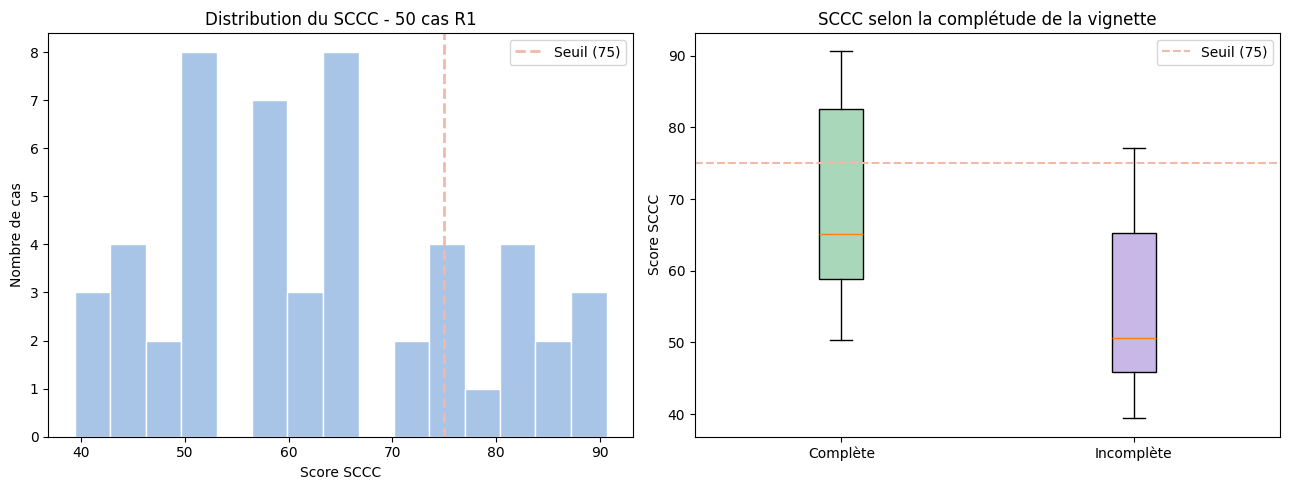

Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Resultats_100_Cas/fig1_sccc_completude.png


In [ ]:
# Première figure — distribution du SCCC et effet de la
# complétude de la vignette. Teste visuellement si le SCCC réagit bien à
# l'information disponible (complète vs incomplète), comme attendu.
SOFT_BLUE = "#A8C5E8"; SOFT_GREEN = "#A8D8B9"; SOFT_CORAL = "#F2B8A8"; SOFT_PURPLE = "#C8B8E8"; SOFT_TEAL = "#8FCFC7"; SOFT_AMBER = "#F2D08A"

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(r1_repondu["sccc_total"], bins=15, color=SOFT_BLUE, edgecolor="white")
axes[0].axvline(SCCC_THRESHOLD, color=SOFT_CORAL, linestyle="--", linewidth=2, label=f"Seuil ({SCCC_THRESHOLD})")
axes[0].set_xlabel("Score SCCC"); axes[0].set_ylabel("Nombre de cas")
axes[0].set_title("Distribution du SCCC - 50 cas R1"); axes[0].legend()

data_by_status = [r1_repondu[r1_repondu["statut_attendu"]==s]["sccc_total"].dropna() for s in ["Complète", "Incomplète"]]
bp = axes[1].boxplot(data_by_status, tick_labels=["Complète", "Incomplète"], patch_artist=True)
for patch, color in zip(bp["boxes"], [SOFT_GREEN, SOFT_PURPLE]):
    patch.set_facecolor(color)
axes[1].axhline(SCCC_THRESHOLD, color=SOFT_CORAL, linestyle="--", label=f"Seuil ({SCCC_THRESHOLD})")
axes[1].set_ylabel("Score SCCC"); axes[1].set_title("SCCC selon la complétude de la vignette"); axes[1].legend()

plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig1_sccc_completude.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig1_sccc_completude.png")

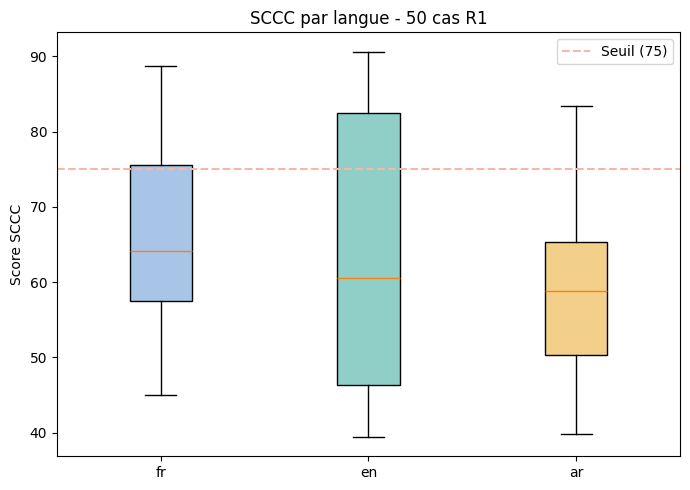

Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Resultats_100_Cas/fig2_sccc_par_langue.png


In [ ]:
# Deuxième figure — SCCC par langue. Teste si l'agent clinique se comporte de façon cohérente entre l'arabe, le français et l'anglais .
fig, ax = plt.subplots(figsize=(7, 5))
langs = ["fr", "en", "ar"]
data_by_lang = [r1_repondu[r1_repondu["langue_reelle"] == l]["sccc_total"].dropna() for l in langs]
bp = ax.boxplot(data_by_lang, tick_labels=langs, patch_artist=True)
for patch, color in zip(bp["boxes"], [SOFT_BLUE, SOFT_TEAL, SOFT_AMBER]):
    patch.set_facecolor(color)
ax.axhline(SCCC_THRESHOLD, color=SOFT_CORAL, linestyle="--", label=f"Seuil ({SCCC_THRESHOLD})")
ax.set_ylabel("Score SCCC"); ax.set_title("SCCC par langue - 50 cas R1"); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig2_sccc_par_langue.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig2_sccc_par_langue.png")

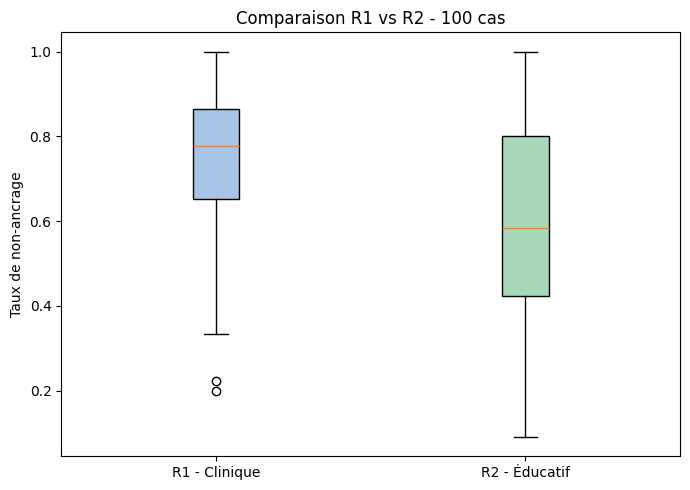

Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Resultats_100_Cas/fig3_ancrage_r1_r2.png


In [ ]:
# Troisième figure — taux de non-ancrage, R1 vs R2.
# Teste si l'agent éducatif (qui reformule davantage) est mesuré différemment
# de l'agent clinique (qui doit citer précisément) par cet indicateur automatique.
fig, ax = plt.subplots(figsize=(7, 5))
data_r1_r2 = [r1_repondu["taux_non_ancrage"].dropna(), r2_repondu["taux_non_ancrage"].dropna()]
bp = ax.boxplot(data_r1_r2, tick_labels=["R1 - Clinique", "R2 - Éducatif"], patch_artist=True)
for patch, color in zip(bp["boxes"], [SOFT_BLUE, SOFT_GREEN]):
    patch.set_facecolor(color)
ax.set_ylabel("Taux de non-ancrage"); ax.set_title("Comparaison R1 vs R2 - 100 cas")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig3_ancrage_r1_r2.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig3_ancrage_r1_r2.png")

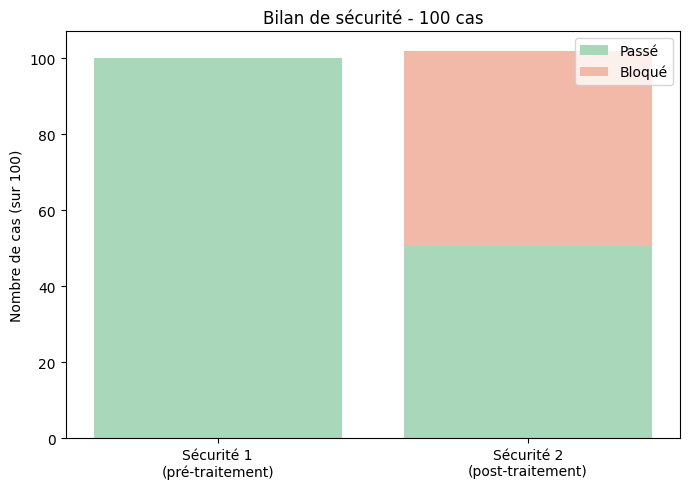

Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Resultats_100_Cas/fig4_bilan_securite.png
\nRappel : ces 100 cas sont des vignettes/questions LÉGITIMES -
un blocage ici signalerait un faux positif à corriger, pas un succès.


In [ ]:
# Quatrième figure — bilan de la sécurité sur les 100 cas.
# Teste si le système bloque à tort du contenu clinique/éducatif légitime (ce qui serait un faux positif problématique), en comptant les statuts de sécurité 1 (pré-traitement) et 2 (post-traitement) cumulés sur R1 + R2.
securite1_bloque = int((r1_df["securite1_crise"] | r1_df["securite1_hors_scope"]).sum() + (r2_df["securite1_crise"] | r2_df["securite1_hors_scope"]).sum())
securite1_passe = 100 - securite1_bloque
securite2_bloque = int((r1_df["securite2_status"] == "bloquee").sum() + (r2_df["securite2_status"] == "bloquee").sum())
securite2_passe = int((r1_df["securite2_status"] == "passee").sum() + (r2_df["securite2_status"] == "passee").sum())

fig, ax = plt.subplots(figsize=(7, 5))
categories = ["Sécurité 1\n(pré-traitement)", "Sécurité 2\n(post-traitement)"]
passes = [securite1_passe, securite2_passe]
bloques = [securite1_bloque, securite2_bloque]
x = range(len(categories))
ax.bar(x, passes, color=SOFT_GREEN, label="Passé")
ax.bar(x, bloques, bottom=passes, color=SOFT_CORAL, label="Bloqué")
ax.set_xticks(list(x)); ax.set_xticklabels(categories)
ax.set_ylabel("Nombre de cas (sur 100)"); ax.set_title("Bilan de sécurité - 100 cas"); ax.legend()
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig4_bilan_securite.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig4_bilan_securite.png")
print(f"\\nRappel : ces 100 cas sont des vignettes/questions LÉGITIMES -")
print(f"un blocage ici signalerait un faux positif à corriger, pas un succès.")

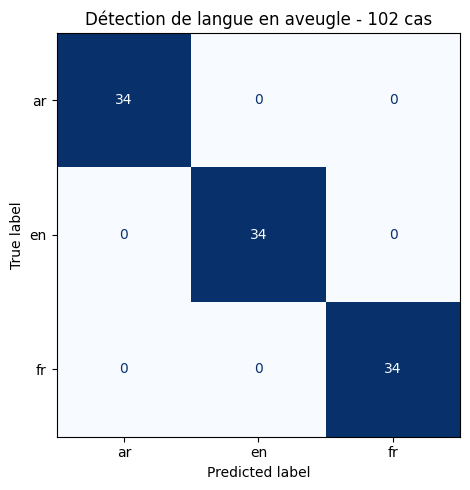

Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Resultats_100_Cas/fig5_confusion_langue.png


In [ ]:
# Cinquième figure — matrice de confusion de la détection de langue en aveugle, sur les 102 cas (51 R1 + 51 R2). Teste si des confusions se concentrent entre certaines langues précises plutôt qu'être réparties au hasard.
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
labels = ["ar", "en", "fr"]
cm = confusion_matrix(toutes_langues["langue_reelle"], toutes_langues["langue_detectee"], labels=labels)
disp = ConfusionMatrixDisplay(cm, display_labels=labels)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Détection de langue en aveugle - 102 cas")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig5_confusion_langue.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig5_confusion_langue.png")

In [ ]:
# Dans cet partie je calcule precision/recall/F1 par classe pour la
# détection de rôle, sur les 102 cas — bien plus robuste que le rapport
# précédent (24 exemples). 
from sklearn.metrics import classification_report

toutes_roles_valides = toutes_roles.dropna(subset=["role_detecte"])
n_ambigus = len(toutes_roles) - len(toutes_roles_valides)

print(f"Couverture : {len(toutes_roles_valides)}/{len(toutes_roles)} cas résolus ({n_ambigus} ambigus)")
print("\n--- Precision / Recall / F1 par classe (102 cas) ---")
print(classification_report(toutes_roles_valides["role_attendu"], toutes_roles_valides["role_detecte"]))

Couverture : 79/102 cas résolus (23 ambigus)

--- Precision / Recall / F1 par classe (102 cas) ---
              precision    recall  f1-score   support

    clinical       1.00      1.00      1.00        45
 educational       1.00      1.00      1.00        34

    accuracy                           1.00        79
   macro avg       1.00      1.00      1.00        79
weighted avg       1.00      1.00      1.00        79



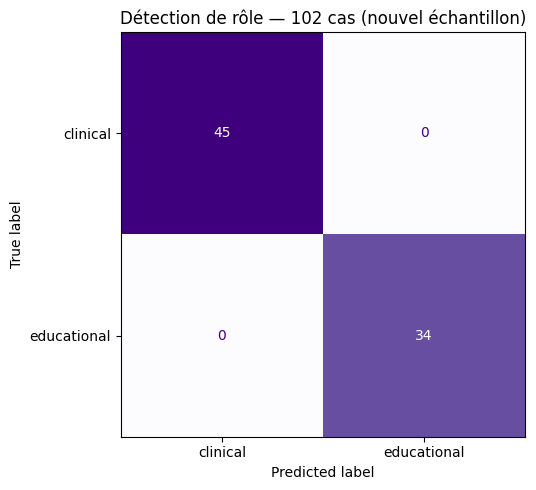

Figure sauvegardée : /content/drive/MyDrive/Master_Thesis_RAG_Indexes/Resultats_100_Cas/fig6_confusion_role_102cas.png


In [ ]:
# Matrice de confusion de la détection de rôle, sur l'échantillon complet de 102 cas 
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(figsize=(6, 5))
labels_role = ["clinical", "educational"]
cm_role = confusion_matrix(toutes_roles_valides["role_attendu"], toutes_roles_valides["role_detecte"], labels=labels_role)
disp = ConfusionMatrixDisplay(cm_role, display_labels=labels_role)
disp.plot(ax=ax, cmap="Purples", colorbar=False)
ax.set_title("Détection de rôle — 102 cas (nouvel échantillon)")
plt.tight_layout()
plt.savefig(f"{RESULTS_DIR}/fig6_confusion_role_102cas.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/fig6_confusion_role_102cas.png")

In [ ]:
# Identifie SI l'échec de détection de rôle se concentre sur certaines pathologies précises, ou est réparti au hasard 
toutes_roles_pathologie = pd.concat([
    r1_df[["pathologie", "role_correct"]],
    r2_df[["pathologie", "role_correct"]]
])
print("Accuracy de détection de rôle par pathologie :")
print(toutes_roles_pathologie.groupby("pathologie")["role_correct"].agg(["mean", "count"]).sort_values("mean"))

Accuracy de détection de rôle par pathologie :
                                           mean  count
pathologie                                            
اضطراب ما بعد الصدمة                   0.428571      7
اكتئاب                                 0.625000      8
Depression                             0.666667      9
فصام                                   0.666667      6
اضطراب ثنائي القطب                     0.666667      6
Schizophrenia                          0.714286      7
PTSD                                   0.750000     12
Dépression                             0.777778      9
Trouble bipolaire                      0.833333      6
Schizophrénie                          0.857143      7
Borderline personality disorder        1.000000      6
Bipolar disorder                       1.000000      6
Trouble de la personnalité borderline  1.000000      6
اضطراب الشخصية الحدية                  1.000000      7
